Business Objective

The objective of this project is to evaluate the effectiveness of marketing spend across different channels and campaigns. The company invests in multiple marketing channels including Search, Paid Social, Email, Referral, and Organic marketing. Leadership wants to understand which channels are actually driving revenue and orders and how the marketing budget should be reallocated to maximize revenue while operating under a fixed budget constraint. By analyzing marketing performance and estimating the impact of spend on revenue, the goal is to propose a data-driven budget allocation plan for the next month.

North Star Metric

The North Star metric chosen for this analysis is:

Incremental Revenue per ₹ Spent

This metric represents how much revenue is generated for every unit of marketing spend. It is closely related to Return on Ad Spend (ROAS) and helps measure marketing efficiency. Maximizing incremental revenue per ₹ spent ensures that marketing investments generate the highest possible return and that budget allocation decisions prioritize high-performing channels.

Supporting KPIs

To support the North Star metric, the following key performance indicators (KPIs) are analyzed:

Return on Ad Spend (ROAS) = Revenue / Marketing Spend

Customer Acquisition Cost (CAC proxy) = Spend / Orders

Conversion Rate (CVR) = Orders / Sessions

Click Through Rate (CTR) = Clicks / Impressions

Cost per Click (CPC) = Spend / Clicks

Revenue per Session = Revenue / Sessions

Average Order Value (AOV) = Revenue / Orders

Discount Rate = Discount Amount / Gross Revenue

Channel Spend Share = Channel Spend / Total Spend

Channel Revenue Share = Channel Revenue / Total Revenue

These KPIs help diagnose marketing performance and identify channels or campaigns that are driving efficient growth.

Attribution Rule

This analysis uses a Last-Touch Attribution model.

Under this rule, each order is attributed to the marketing channel and campaign associated with the session that directly preceded the purchase. This approach assumes that the final marketing interaction played the most influential role in driving the conversion.

Last-touch attribution is widely used in marketing analytics because it is simple to implement and provides a clear view of which channels are directly responsible for conversions.

Stakeholder Questions

The analysis aims to answer the following key business questions:

Which marketing channels generate the highest revenue and orders?

Which campaigns deliver the best return on ad spend?

Are there channels or campaigns where marketing spend is inefficient or wasted?

How do conversion rates differ across channels, devices, and user segments?

Which customer segments generate the highest marketing return?

How does marketing performance change over time?

How should next month’s marketing budget be reallocated to maximize revenue?

In [1]:
import pandas as pd
import numpy as np
import json

In [3]:
data_path = "../data/"

In [4]:
users = pd.read_csv(data_path + "users.csv")
campaigns = pd.read_csv(data_path + "campaigns.csv")
ad_spend = pd.read_csv(data_path + "ad_spend_daily.csv")
sessions = pd.read_csv(data_path + "sessions.csv")
orders = pd.read_csv(data_path + "orders.csv")
order_items = pd.read_csv(data_path + "order_items.csv")

In [5]:
with open(data_path + "products.json") as f:
    products = pd.DataFrame(json.load(f))

In [6]:
print("Users:", users.shape)
print("Campaigns:", campaigns.shape)
print("Ad Spend:", ad_spend.shape)
print("Sessions:", sessions.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)

Users: (2600, 5)
Campaigns: (40, 4)
Ad Spend: (8461, 8)
Sessions: (659793, 6)
Orders: (16225, 8)
Order Items: (40456, 4)
Products: (240, 6)


In [7]:
users.head()

,user_id,signup_date,city_tier,segment,preferred_device
0,U000001,2025-12-30,3,regular,web
1,U000002,2025-05-25,1,regular,web
2,U000003,2025-09-01,2,value,web
3,U000004,2025-12-24,2,premium,mobile
4,U000005,2025-06-15,2,value,mobile


In [8]:
sessions.head()

,session_id,user_id,session_ts,device,channel,campaign_id
0,S00000001,U001881,2025-07-04T16:50:13,mobile,search,C001
1,S00000002,U001667,2025-07-04T06:09:01,web,search,C001
2,S00000003,U001894,2025-07-04T03:57:40,web,search,C001
3,S00000004,U000828,2025-07-04T10:05:10,mobile,search,C001
4,S00000005,U002073,2025-07-04T17:03:50,mobile,search,C001


In [9]:
orders.head()

,order_id,session_id,user_id,order_ts,gross_amount,discount_amount,shipping_amount,net_amount
0,O00000001,S00000002,U001667,2025-07-04T06:17:29,12869.16,2261.63,0.0,10607.53
1,O00000002,S00000018,U001077,2025-07-04T21:41:35,12537.13,1328.78,0.0,11208.35
2,O00000003,S00000088,U002260,2025-07-04T05:26:18,7783.09,892.60,0.0,6890.49
3,O00000004,S00000173,U001816,2025-07-05T21:34:07,12458.61,505.26,0.0,11953.35
4,O00000005,S00000188,U002414,2025-07-05T03:19:20,10186.43,400.94,0.0,9785.49


In [11]:
campaigns.head()

,campaign_id,channel,campaign_name,objective
0,C001,search,search_camp_001,acquisition
1,C002,search,search_camp_002,acquisition
2,C003,search,search_camp_003,acquisition
3,C004,search,search_camp_004,acquisition
4,C005,search,search_camp_005,acquisition


In [12]:
ad_spend.head()

,date,day_idx,promo_flag,campaign_id,channel,spend,impressions,clicks
0,2025-07-04,0,1,C001,search,26312.21,100619,2173
1,2025-07-04,0,1,C002,search,21647.84,87070,3103
2,2025-07-04,0,1,C003,search,22354.06,92590,1931
3,2025-07-04,0,1,C004,search,26270.94,112017,3485
4,2025-07-04,0,1,C005,search,22875.24,88620,2460


In [13]:
print("Users missing values:\n", users.isnull().sum(), "\n")
print("Campaigns missing values:\n", campaigns.isnull().sum(), "\n")
print("Ad Spend missing values:\n", ad_spend.isnull().sum(), "\n")
print("Sessions missing values:\n", sessions.isnull().sum(), "\n")
print("Orders missing values:\n", orders.isnull().sum(), "\n")
print("Order Items missing values:\n", order_items.isnull().sum(), "\n")
print("Products missing values:\n", products.isnull().sum())

Users missing values:
 user_id              0
signup_date          0
city_tier            0
segment              0
preferred_device    26
dtype: int64 

Campaigns missing values:
 campaign_id      0
channel          0
campaign_name    0
objective        0
dtype: int64 

Ad Spend missing values:
 date            0
day_idx         0
promo_flag      0
campaign_id     0
channel         0
spend          50
impressions     0
clicks          0
dtype: int64 

Sessions missing values:
 session_id          0
user_id        105749
session_ts          0
device           4612
channel             0
campaign_id         0
dtype: int64 

Orders missing values:
 order_id              0
session_id            0
user_id            2499
order_ts              0
gross_amount          0
discount_amount       0
shipping_amount       0
net_amount            0
dtype: int64 

Order Items missing values:
 order_id      0
product_id    0
quantity      0
unit_price    0
dtype: int64 

Products missing values:
 produc

In [14]:
print("Users duplicates:", users.duplicated().sum())
print("Campaigns duplicates:", campaigns.duplicated().sum())
print("Ad Spend duplicates:", ad_spend.duplicated().sum())
print("Sessions duplicates:", sessions.duplicated().sum())
print("Orders duplicates:", orders.duplicated().sum())
print("Order Items duplicates:", order_items.duplicated().sum())

Users duplicates: 0
Campaigns duplicates: 0
Ad Spend duplicates: 21
Sessions duplicates: 1973
Orders duplicates: 32
Order Items duplicates: 0


In [15]:
sessions["channel"].value_counts()

channel
search         222387
paid_social    195321
organic        121256
email           69180
referral        45050
Search           1140
SEARCH           1105
Paid_Social       991
PAID_SOCIAL       974
ORGANIC           654
Organic           601
EMAIL             350
Email             315
REFERRAL          237
Referral          232
Name: count, dtype: int64

In [16]:
campaigns["channel"].value_counts()

channel
search         8
paid_social    8
email          8
referral       8
organic        8
Name: count, dtype: int64

In [17]:
ad_spend = ad_spend.drop_duplicates()
sessions = sessions.drop_duplicates()
orders = orders.drop_duplicates()

In [18]:
sessions["channel"] = sessions["channel"].str.lower()
campaigns["channel"] = campaigns["channel"].str.lower()
ad_spend["channel"] = ad_spend["channel"].str.lower()

In [19]:
sessions["channel"].value_counts()

channel
search         224003
paid_social    196678
organic        122120
email           69630
referral        45389
Name: count, dtype: int64

In [20]:
fact_sessions = sessions.merge(
    orders[["session_id", "order_id", "gross_amount", "discount_amount", "net_amount"]],
    on="session_id",
    how="left"
)

In [21]:
fact_sessions["purchase_flag"] = fact_sessions["order_id"].notna().astype(int)

In [22]:
fact_sessions["gross_amount"] = fact_sessions["gross_amount"].fillna(0)
fact_sessions["discount_amount"] = fact_sessions["discount_amount"].fillna(0)
fact_sessions["net_amount"] = fact_sessions["net_amount"].fillna(0)

In [23]:
fact_sessions.head()

,session_id,user_id,session_ts,device,channel,campaign_id,order_id,gross_amount,discount_amount,net_amount,purchase_flag
0,S00000001,U001881,2025-07-04T16:50:13,mobile,search,C001,NaN,0.00,0.00,0.00,0
1,S00000002,U001667,2025-07-04T06:09:01,web,search,C001,O00000001,12869.16,2261.63,10607.53,1
2,S00000003,U001894,2025-07-04T03:57:40,web,search,C001,NaN,0.00,0.00,0.00,0
3,S00000004,U000828,2025-07-04T10:05:10,mobile,search,C001,NaN,0.00,0.00,0.00,0
4,S00000005,U002073,2025-07-04T17:03:50,mobile,search,C001,NaN,0.00,0.00,0.00,0


In [24]:
fact_sessions.shape

(657820, 11)

In [26]:
fact_sessions["purchase_flag"].value_counts()

purchase_flag
0    641627
1     16193
Name: count, dtype: int64

In [27]:
fact_sessions = fact_sessions.merge(
    users[["user_id", "signup_date"]],
    on="user_id",
    how="left"
)

In [28]:
fact_sessions["session_ts"] = pd.to_datetime(fact_sessions["session_ts"])
fact_sessions["signup_date"] = pd.to_datetime(fact_sessions["signup_date"])

In [29]:
fact_sessions["is_new_user"] = (
    fact_sessions["session_ts"].dt.date == fact_sessions["signup_date"].dt.date
).astype(int)

In [30]:
fact_sessions["is_new_user"].value_counts()

is_new_user
0    656021
1      1799
Name: count, dtype: int64

In [31]:
fact_sessions.shape

(657820, 13)

In [32]:
fact_sessions.to_csv("../data/fact_sessions.csv", index=False)

In [34]:
fact_sessions["date"] = fact_sessions["session_ts"].dt.date

In [35]:
fact_sessions[["session_ts", "date"]].head()

,session_ts,date
0,2025-07-04 16:50:13,2025-07-04
1,2025-07-04 06:09:01,2025-07-04
2,2025-07-04 03:57:40,2025-07-04
3,2025-07-04 10:05:10,2025-07-04
4,2025-07-04 17:03:50,2025-07-04


In [36]:
sessions_campaign_daily = fact_sessions.groupby(
    ["date", "campaign_id", "channel"]
).agg(
    sessions=("session_id", "count"),
    orders=("purchase_flag", "sum"),
    revenue=("net_amount", "sum")
).reset_index()

In [38]:
sessions_campaign_daily.head()

,date,campaign_id,channel,sessions,orders,revenue
0,2025-07-04,C001,search,140,3,28706.37
1,2025-07-04,C002,search,140,4,17676.27
2,2025-07-04,C003,search,140,9,55752.12
3,2025-07-04,C004,search,140,7,33388.35
4,2025-07-04,C005,search,140,3,25908.70


In [39]:
sessions_campaign_daily.shape

(8432, 6)

In [40]:
fact_campaign_daily = sessions_campaign_daily.merge(
    ad_spend[
        ["date", "campaign_id", "channel", "spend", "impressions", "clicks"]
    ],
    on=["date", "campaign_id", "channel"],
    how="left"
)

In [41]:
fact_campaign_daily.head()

,date,campaign_id,channel,sessions,orders,revenue,spend,impressions,clicks
0,2025-07-04,C001,search,140,3,28706.37,NaN,NaN,NaN
1,2025-07-04,C002,search,140,4,17676.27,NaN,NaN,NaN
2,2025-07-04,C003,search,140,9,55752.12,NaN,NaN,NaN
3,2025-07-04,C004,search,140,7,33388.35,NaN,NaN,NaN
4,2025-07-04,C005,search,140,3,25908.70,NaN,NaN,NaN


In [42]:
fact_campaign_daily.shape

(8432, 9)

In [43]:
ad_spend["date"] = pd.to_datetime(ad_spend["date"]).dt.date

In [44]:
ad_spend.head()

,date,day_idx,promo_flag,campaign_id,channel,spend,impressions,clicks
0,2025-07-04,0,1,C001,search,26312.21,100619,2173
1,2025-07-04,0,1,C002,search,21647.84,87070,3103
2,2025-07-04,0,1,C003,search,22354.06,92590,1931
3,2025-07-04,0,1,C004,search,26270.94,112017,3485
4,2025-07-04,0,1,C005,search,22875.24,88620,2460


In [45]:
fact_campaign_daily = sessions_campaign_daily.merge(
    ad_spend[
        ["date", "campaign_id", "channel", "spend", "impressions", "clicks"]
    ],
    on=["date", "campaign_id", "channel"],
    how="left"
)

In [46]:
fact_campaign_daily.head()

,date,campaign_id,channel,sessions,orders,revenue,spend,impressions,clicks
0,2025-07-04,C001,search,140,3,28706.37,26312.21,100619,2173
1,2025-07-04,C002,search,140,4,17676.27,21647.84,87070,3103
2,2025-07-04,C003,search,140,9,55752.12,22354.06,92590,1931
3,2025-07-04,C004,search,140,7,33388.35,26270.94,112017,3485
4,2025-07-04,C005,search,140,3,25908.70,22875.24,88620,2460


In [47]:
fact_campaign_daily.isnull().sum()

date            0
campaign_id     0
channel         0
sessions        0
orders          0
revenue         0
spend          50
impressions     0
clicks          0
dtype: int64

In [48]:
fact_campaign_daily["spend"] = fact_campaign_daily["spend"].fillna(0)

In [49]:
fact_campaign_daily.isnull().sum()

date           0
campaign_id    0
channel        0
sessions       0
orders         0
revenue        0
spend          0
impressions    0
clicks         0
dtype: int64

In [50]:
fact_campaign_daily["CPC"] = fact_campaign_daily["spend"] / fact_campaign_daily["clicks"]

fact_campaign_daily["CTR"] = fact_campaign_daily["clicks"] / fact_campaign_daily["impressions"]

fact_campaign_daily["CVR"] = fact_campaign_daily["orders"] / fact_campaign_daily["sessions"]

fact_campaign_daily["ROAS"] = fact_campaign_daily["revenue"] / fact_campaign_daily["spend"]

fact_campaign_daily["CAC"] = fact_campaign_daily["spend"] / fact_campaign_daily["orders"]

In [51]:
fact_campaign_daily = fact_campaign_daily.replace([np.inf, -np.inf], 0)

In [52]:
fact_campaign_daily.head()

,date,campaign_id,channel,sessions,orders,revenue,spend,impressions,clicks,CPC,CTR,CVR,ROAS,CAC
0,2025-07-04,C001,search,140,3,28706.37,26312.21,100619,2173,12.108702,0.021596,0.021429,1.090990,8770.736667
1,2025-07-04,C002,search,140,4,17676.27,21647.84,87070,3103,6.976423,0.035638,0.028571,0.816537,5411.960000
2,2025-07-04,C003,search,140,9,55752.12,22354.06,92590,1931,11.576416,0.020855,0.064286,2.494049,2483.784444
3,2025-07-04,C004,search,140,7,33388.35,26270.94,112017,3485,7.538290,0.031111,0.050000,1.270923,3752.991429
4,2025-07-04,C005,search,140,3,25908.70,22875.24,88620,2460,9.298878,0.027759,0.021429,1.132609,7625.080000


In [53]:
fact_channel_daily = fact_campaign_daily.groupby(
    ["date", "channel"]
).agg(
    sessions=("sessions","sum"),
    orders=("orders","sum"),
    revenue=("revenue","sum"),
    spend=("spend","sum"),
    impressions=("impressions","sum"),
    clicks=("clicks","sum")
).reset_index()

In [54]:
fact_channel_daily["CPC"] = fact_channel_daily["spend"] / fact_channel_daily["clicks"]

fact_channel_daily["CTR"] = fact_channel_daily["clicks"] / fact_channel_daily["impressions"]

fact_channel_daily["CVR"] = fact_channel_daily["orders"] / fact_channel_daily["sessions"]

fact_channel_daily["ROAS"] = fact_channel_daily["revenue"] / fact_channel_daily["spend"]

fact_channel_daily["CAC"] = fact_channel_daily["spend"] / fact_channel_daily["orders"]

In [55]:
fact_channel_daily = fact_channel_daily.replace([np.inf, -np.inf], 0)

In [56]:
fact_channel_daily.head()

,date,channel,sessions,orders,revenue,spend,impressions,clicks,CPC,CTR,CVR,ROAS,CAC
0,2025-07-04,email,418,20,123248.30,19566.32,424886,4484,4.363586,0.010553,0.047847,6.299003,978.316000
1,2025-07-04,organic,696,14,64098.51,5380.51,620736,7272,0.739894,0.011715,0.020115,11.913092,384.322143
2,2025-07-04,paid_social,991,30,152446.28,157932.61,856233,15201,10.389620,0.017753,0.030272,0.965262,5264.420333
3,2025-07-04,referral,201,6,37622.67,32210.79,114693,2305,13.974312,0.020097,0.029851,1.168015,5368.465000
4,2025-07-04,search,1120,43,243962.18,188257.71,783751,21862,8.611184,0.027894,0.038393,1.295895,4378.086279


In [57]:
fact_channel_daily.shape

(1055, 13)

In [63]:
import os

os.makedirs("data/processed", exist_ok=True)

In [73]:
fact_channel_daily.to_csv("data/processed/fact_channel_daily.csv", index=False)


In [76]:
fact_campaign_daily.to_csv("../data/processed/fact_campaign_daily.csv", index=False)

In [77]:
purchase_sessions = fact_sessions[fact_sessions["purchase_flag"] == 1]

In [78]:
last_touch_attribution = purchase_sessions.groupby("channel").agg(
    orders=("order_id", "count"),
    revenue=("net_amount", "sum")
).reset_index()

In [79]:
last_touch_attribution

,channel,orders,revenue
0,email,3003,19250984.14
1,organic,1999,12400693.30
2,paid_social,3203,19095173.73
3,referral,1307,8748854.47
4,search,6681,45558637.31


In [80]:
channel_spend = fact_channel_daily.groupby("channel")["spend"].sum().reset_index()

In [81]:
last_touch_attribution = last_touch_attribution.merge(
    channel_spend,
    on="channel",
    how="left"
)

In [82]:
last_touch_attribution["ROAS"] = last_touch_attribution["revenue"] / last_touch_attribution["spend"]

In [83]:
last_touch_attribution = last_touch_attribution.sort_values(by="ROAS", ascending=False)

In [84]:
last_touch_attribution

,channel,orders,revenue,spend,ROAS
1,organic,1999,12400693.30,954686.60,12.989282
0,email,3003,19250984.14,3811103.47,5.051289
4,search,6681,45558637.31,34333235.87,1.326954
3,referral,1307,8748854.47,6669377.76,1.311795
2,paid_social,3203,19095173.73,28586495.57,0.667979


In [85]:
first_sessions = fact_sessions.sort_values("session_ts").groupby("user_id").first().reset_index()

In [89]:
purchased_users = purchase_sessions["user_id"].unique()

first_touch_sessions = first_sessions[first_sessions["user_id"].isin(purchased_users)]

In [90]:
first_touch_attribution = first_touch_sessions.groupby("channel").agg(
    users_acquired=("user_id","count")
).reset_index()

In [91]:
first_touch_attribution

,channel,users_acquired
0,email,330
1,organic,507
2,paid_social,733
3,referral,158
4,search,855


In [92]:
user_sessions = fact_sessions.groupby("user_id").size().reset_index(name="session_count")

In [93]:
linear_data = fact_sessions.merge(user_sessions, on="user_id", how="left")

In [94]:
linear_data["credit"] = 1 / linear_data["session_count"]

In [95]:
linear_purchase = linear_data[linear_data["purchase_flag"] == 1]

linear_attribution = linear_purchase.groupby("channel").agg(
    credit=("credit","sum"),
    revenue=("net_amount","sum")
).reset_index()

In [96]:
linear_attribution = linear_purchase.groupby("channel").agg(
    credit=("credit","sum"),
    revenue=("net_amount","sum")
).reset_index()

In [97]:
linear_attribution

,channel,credit,revenue
0,email,11.923596,19250984.14
1,organic,7.855497,12400693.30
2,paid_social,12.808359,19095173.73
3,referral,5.238428,8748854.47
4,search,26.632853,45558637.31


In [98]:
channel_pivot = fact_channel_daily.pivot_table(
    index="date",
    columns="channel",
    values="spend",
    aggfunc="sum"
).reset_index()

In [99]:
daily_revenue = fact_channel_daily.groupby("date")["revenue"].sum().reset_index()

In [100]:
regression_data = channel_pivot.merge(daily_revenue, on="date")

In [101]:
regression_data.head()

,date,email,organic,paid_social,referral,search,revenue
0,2025-07-04,19566.32,5380.51,157932.61,32210.79,188257.71,621377.94
1,2025-07-05,18352.15,4010.76,130147.97,32529.45,159676.14,418793.94
2,2025-07-06,17708.52,4565.21,126196.48,29244.95,164394.80,378668.50
3,2025-07-07,16110.20,3856.91,117923.28,29280.44,142097.27,542583.45
4,2025-07-08,16823.84,3983.43,112896.66,28023.88,164299.43,487601.84


In [102]:
from sklearn.linear_model import LinearRegression

In [103]:
X = regression_data[["email","organic","paid_social","referral","search"]]

y = regression_data["revenue"]

In [104]:
model = LinearRegression()

model.fit(X,y)

LinearRegression()

In [105]:
coefficients = pd.DataFrame({
    "channel": X.columns,
    "impact_coefficient": model.coef_
})

coefficients

,channel,impact_coefficient
0,email,-0.532025
1,organic,15.718105
2,paid_social,1.022266
3,referral,3.650521
4,search,0.906653


In [106]:
total_spend = regression_data[["email","organic","paid_social","referral","search"]].sum()

total_spend

email           3811103.47
organic          954686.60
paid_social    28586495.57
referral        6669377.76
search         34333235.87
dtype: float64

In [107]:
new_budget = {
    "organic": total_spend.sum()*0.35,
    "search": total_spend.sum()*0.25,
    "referral": total_spend.sum()*0.20,
    "paid_social": total_spend.sum()*0.15,
    "email": total_spend.sum()*0.05
}

In [108]:
new_budget_df = pd.DataFrame(list(new_budget.items()), columns=["channel","new_spend"])

new_budget_df

,channel,new_spend
0,organic,2.602421e+07
1,search,1.858872e+07
2,referral,1.487098e+07
3,paid_social,1.115323e+07
4,email,3.717745e+06


In [109]:
budget_simulation = new_budget_df.merge(coefficients, on="channel")

budget_simulation["expected_revenue"] = budget_simulation["new_spend"] * budget_simulation["impact_coefficient"]

budget_simulation

,channel,new_spend,impact_coefficient,expected_revenue
0,organic,2.602421e+07,15.718105,4.090513e+08
1,search,1.858872e+07,0.906653,1.685352e+07
2,referral,1.487098e+07,3.650521,5.428683e+07
3,paid_social,1.115323e+07,1.022266,1.140157e+07
4,email,3.717745e+06,-0.532025,-1.977934e+06


In [110]:
channel_perf = fact_channel_daily.groupby("channel").agg({
    "orders":"sum",
    "revenue":"sum",
    "spend":"sum"
}).reset_index()

channel_perf["ROAS"] = channel_perf["revenue"] / channel_perf["spend"]
channel_perf["CAC_proxy"] = channel_perf["spend"] / channel_perf["orders"]

channel_perf.sort_values("revenue", ascending=False)

,channel,orders,revenue,spend,ROAS,CAC_proxy
4,search,6681,45558637.31,34333235.87,1.326954,5138.936667
0,email,3003,19250984.14,3811103.47,5.051289,1269.098725
2,paid_social,3203,19095173.73,28586495.57,0.667979,8924.912760
1,organic,1999,12400693.30,954686.60,12.989282,477.582091
3,referral,1307,8748854.47,6669377.76,1.311795,5102.813894


In [111]:
top_spend_campaigns = fact_campaign_daily.groupby("campaign_id").agg({
    "spend":"sum",
    "revenue":"sum",
    "orders":"sum"
}).reset_index()

top_spend_campaigns = top_spend_campaigns.sort_values("spend", ascending=False).head(5)

top_spend_campaigns

,campaign_id,spend,revenue,orders
0,C001,4369244.94,5479447.65,809
1,C002,4328266.00,6183917.98,867
5,C006,4327050.43,5750836.33,848
7,C008,4320160.64,5551850.62,828
3,C004,4288198.93,5175585.24,788


In [112]:
top_revenue_campaigns = fact_campaign_daily.groupby("campaign_id").agg({
    "revenue":"sum",
    "spend":"sum",
    "orders":"sum"
}).reset_index()

top_revenue_campaigns = top_revenue_campaigns.sort_values("revenue", ascending=False).head(5)

top_revenue_campaigns

,campaign_id,revenue,spend,orders
1,C002,6183917.98,4328266.00,867
6,C007,6042963.38,4285939.27,853
5,C006,5750836.33,4327050.43,848
2,C003,5705047.59,4272019.15,837
4,C005,5668988.52,4142356.51,851


In [113]:
fact_campaign_daily["ROAS"] = fact_campaign_daily["revenue"] / fact_campaign_daily["spend"]

wasted_spend = fact_campaign_daily.groupby("campaign_id").agg({
    "spend":"sum",
    "revenue":"sum",
    "ROAS":"mean"
}).reset_index()

wasted_spend = wasted_spend.sort_values("ROAS").head(5)

wasted_spend

,campaign_id,spend,revenue,ROAS
15,C016,3624551.23,2249073.35,0.656674
13,C014,3587281.51,2370560.35,0.678051
14,C015,3526893.92,2434463.52,0.699921
29,C030,820740.61,823035.38,0.992538
27,C028,841543.46,992213.90,1.253701


Marketing Performance Diagnosis

The analysis of channel-level performance reveals clear differences in marketing efficiency across channels.

Search generates the highest total revenue (₹45.56M) and the largest number of orders (6,681), making it the most important revenue-driving channel. However, search also consumes the largest share of marketing spend (₹34.33M), resulting in a moderate ROAS of 1.33.

Organic marketing shows the highest efficiency, with a ROAS of 12.99 while spending less than ₹1M. This indicates that organic traffic delivers significantly more revenue per unit of spend and is the most cost-efficient acquisition channel.

Email marketing also performs strongly with a ROAS of 5.05 and relatively low CAC compared to other paid channels. In contrast, paid social campaigns show the lowest efficiency with a ROAS of 0.67, meaning the company is spending more on this channel relative to the revenue it generates.

At the campaign level, campaigns C002, C007, and C006 generate the highest revenue, while campaigns C016, C014, and C015 show low ROAS despite relatively high spend. These campaigns are potential candidates for optimization or budget reduction.

Overall, the analysis suggests that increasing investment in high-performing channels such as organic and email while reviewing underperforming paid campaigns could improve overall marketing ROI.

Daily or weekly trends for key marketing KPIs

In [114]:
daily_kpis = fact_channel_daily.groupby("date").agg({
    "revenue":"sum",
    "spend":"sum",
    "orders":"sum"
}).reset_index()

daily_kpis["ROAS"] = daily_kpis["revenue"] / daily_kpis["spend"]

daily_kpis.head()

,date,revenue,spend,orders,ROAS
0,2025-07-04,621377.94,403347.94,113,1.540551
1,2025-07-05,418793.94,344716.47,73,1.214894
2,2025-07-06,378668.50,342109.96,57,1.106862
3,2025-07-07,542583.45,309268.10,80,1.754411
4,2025-07-08,487601.84,326027.24,74,1.495586


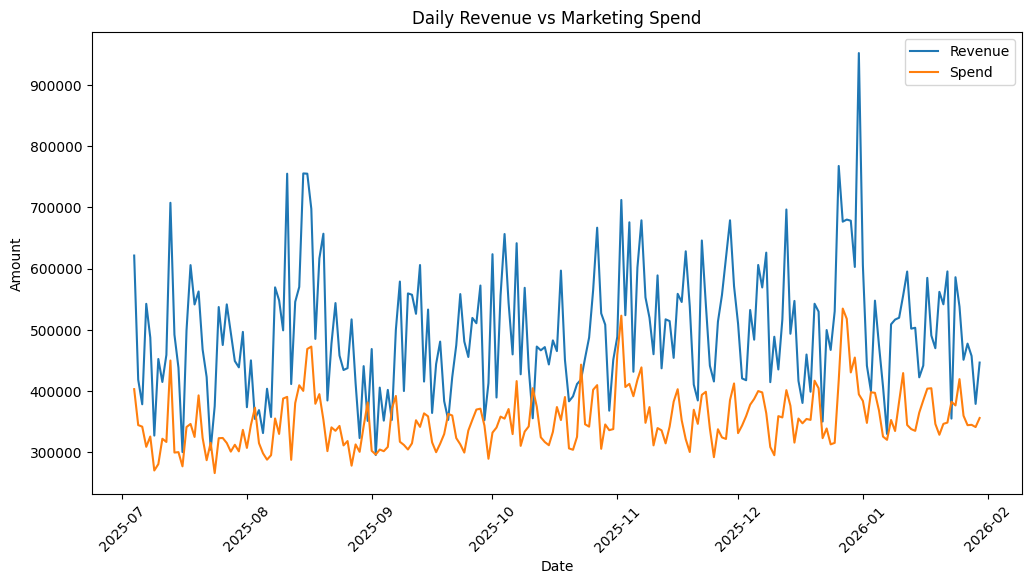

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(daily_kpis["date"], daily_kpis["revenue"], label="Revenue")
plt.plot(daily_kpis["date"], daily_kpis["spend"], label="Spend")

plt.title("Daily Revenue vs Marketing Spend")
plt.xlabel("Date")
plt.ylabel("Amount")
plt.legend()
plt.xticks(rotation=45)
plt.show()

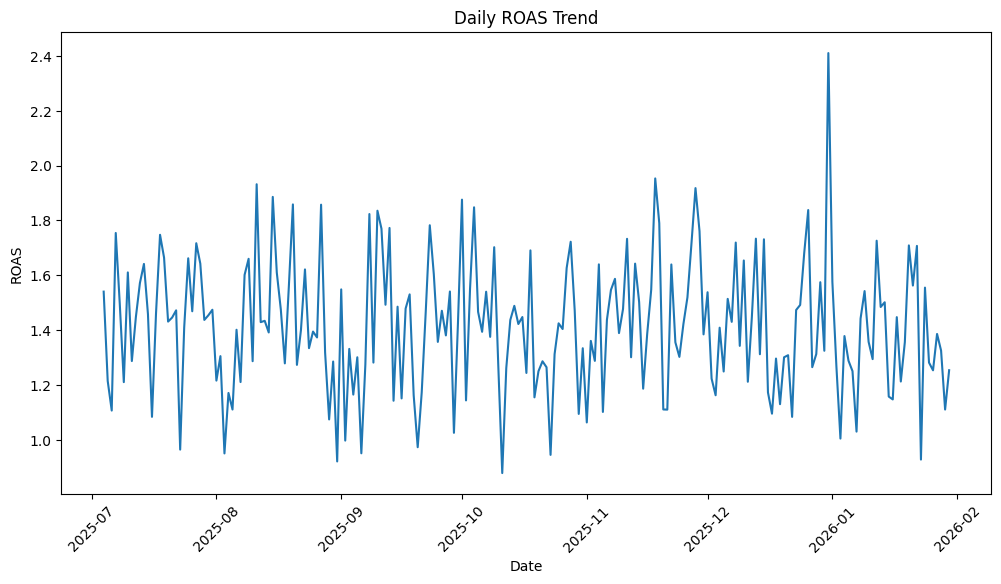

In [116]:
plt.figure(figsize=(12,6))
plt.plot(daily_kpis["date"], daily_kpis["ROAS"])

plt.title("Daily ROAS Trend")
plt.xlabel("Date")
plt.ylabel("ROAS")
plt.xticks(rotation=45)
plt.show()

KPI Trends Analysis
Daily Revenue vs Marketing Spend

The daily trend analysis shows that revenue consistently exceeds marketing spend throughout the observation period, indicating that marketing investments generally generate positive returns. However, both revenue and spend fluctuate significantly across days, suggesting variability in campaign performance and customer demand.

Several spikes in revenue can be observed during certain periods, likely corresponding to promotional campaigns, seasonal demand, or higher campaign activity. Marketing spend appears relatively stable but increases slightly during high-performance periods, indicating that higher investment sometimes coincides with stronger revenue generation.

ROAS Trend

The ROAS (Return on Ad Spend) trend fluctuates between approximately 1.0 and 2.4, indicating varying marketing efficiency across time. Most days show ROAS values above 1, meaning the marketing spend generally generates more revenue than cost.

Occasional spikes in ROAS suggest periods where marketing campaigns performed exceptionally well relative to the amount spent. Conversely, some dips close to 1 indicate periods where marketing efficiency was lower, potentially due to ineffective campaigns or lower consumer demand.

These fluctuations highlight the importance of continuous performance monitoring and optimizing campaign allocation to maintain high marketing efficiency.

In [117]:
channel_device = fact_sessions.groupby(["channel","device"]).agg({
    "purchase_flag":"sum",
    "net_amount":"sum",
    "session_id":"count"
}).reset_index()

channel_device.rename(columns={
    "purchase_flag":"orders",
    "session_id":"sessions",
    "net_amount":"revenue"
}, inplace=True)

channel_device["conversion_rate"] = channel_device["orders"] / channel_device["sessions"]

channel_device.sort_values("revenue", ascending=False)

,channel,device,orders,revenue,sessions,conversion_rate
9,search,web,4215,28613225.49,128863,0.032709
8,search,mobile,2413,16598981.78,93563,0.025790
1,email,web,1807,11406411.65,39900,0.045288
5,paid_social,web,1736,10257567.79,87547,0.019829
4,paid_social,mobile,1443,8688355.68,107756,0.013391
0,email,mobile,1166,7641560.00,29243,0.039873
3,organic,web,1077,6673280.85,54683,0.019695
7,referral,web,834,5651264.37,26060,0.032003
2,organic,mobile,908,5648668.71,66599,0.013634
6,referral,mobile,462,3045716.72,19002,0.024313


Channel × Device Performance Analysis

The channel and device analysis reveals significant differences in conversion performance across platforms.

Search traffic generates the highest revenue on both devices, particularly on web where it produces over ₹28.6M in revenue with a conversion rate of 3.27%. Mobile search also performs strongly but slightly below web, suggesting that users searching on desktop may have higher purchase intent.

Email marketing shows the highest conversion rates overall, with 4.53% on web and 3.99% on mobile, indicating that email campaigns are very effective at converting users who already have some level of engagement with the brand.

Paid social traffic has lower conversion rates compared to search and email, particularly on mobile where the conversion rate drops to 1.34%. This suggests that paid social is likely more effective for awareness and user acquisition rather than direct conversions.

Organic and referral traffic perform moderately well, with web traffic consistently converting better than mobile traffic. Overall, the results suggest that web traffic generally converts better than mobile across most channels, highlighting the importance of optimizing mobile experiences to improve conversion rates.

In [118]:
user_type = fact_sessions.groupby("is_new_user").agg({
    "session_id":"count",
    "purchase_flag":"sum",
    "net_amount":"sum"
}).reset_index()

user_type.rename(columns={
    "session_id":"sessions",
    "purchase_flag":"orders",
    "net_amount":"revenue"
}, inplace=True)

user_type["conversion_rate"] = user_type["orders"] / user_type["sessions"]

user_type

,is_new_user,sessions,orders,revenue,conversion_rate
0,0,656021,16144,1.047738e+08,0.024609
1,1,1799,49,2.805383e+05,0.027237


New vs Returning User Analysis

The comparison between new and returning users shows differences in conversion behavior.

Returning users account for the majority of traffic with 656,021 sessions and 16,144 orders, generating approximately ₹104.7M in revenue. Their conversion rate is 2.46%, which reflects the typical behavior of users who revisit the platform before making purchases.

New users represent a much smaller portion of sessions (1,799 sessions) but show a slightly higher conversion rate of 2.72%. This suggests that new users who arrive on the platform may already have strong purchase intent, possibly driven by targeted marketing campaigns or promotions.

However, returning users generate significantly more overall revenue due to the much larger volume of sessions. This highlights the importance of both customer acquisition and retention strategies. While attracting new customers is essential for growth, maintaining engagement with returning users is critical for sustaining long-term revenue.

In [119]:
city_perf = fact_sessions.merge(users, on="user_id")

city_perf = city_perf.groupby("city_tier").agg({
    "session_id":"count",
    "purchase_flag":"sum",
    "net_amount":"sum"
}).reset_index()

city_perf.rename(columns={
    "session_id":"sessions",
    "purchase_flag":"orders",
    "net_amount":"revenue"
}, inplace=True)

city_perf["conversion_rate"] = city_perf["orders"] / city_perf["sessions"]

city_perf.sort_values("revenue", ascending=False)

,city_tier,sessions,orders,revenue,conversion_rate
1,2,275741,6753,43813830.36,0.024490
0,1,139871,3542,23149870.05,0.025323
2,3,136798,3405,22032556.41,0.024891


City Tier Performance Analysis

The city tier analysis shows how customer behavior varies across different geographic segments.

City Tier 2 generates the highest total revenue (₹43.8M) and the largest number of orders (6,753), indicating that this segment contributes the most to overall business performance. This may be due to a larger population base or stronger marketing reach in mid-tier cities.

City Tier 1 has the highest conversion rate at 2.53%, suggesting that users in top-tier cities are slightly more likely to convert once they visit the platform. These users may have higher purchasing power or stronger brand familiarity.

City Tier 3 produces similar conversion rates to the other tiers but contributes slightly lower overall revenue due to lower session volume.

Overall, the results indicate that City Tier 2 drives the largest volume of revenue, while City Tier 1 shows slightly higher conversion efficiency. Marketing strategies may benefit from maintaining strong presence in Tier 2 cities while improving targeting and campaign optimization in Tier 3 regions.

In [120]:
product_perf = (
    order_items
    .merge(products, on="product_id")
    .merge(orders[["order_id","net_amount"]], on="order_id")
)

category_perf = product_perf.groupby("category").agg({
    "quantity":"sum",
    "net_amount":"sum"
}).reset_index()

category_perf.rename(columns={
    "net_amount":"revenue"
}, inplace=True)

category_perf.sort_values("revenue", ascending=False)

,category,quantity,revenue
1,Books,15521,63158542.18
3,Fashion,15416,61917005.70
5,Sports,15484,59276222.83
4,Home,13838,55174971.90
0,Beauty,10886,41529290.51
2,Electronics,9649,34694858.51


Product Category Performance Analysis

The product category analysis shows how revenue and demand vary across different product segments.

Books generate the highest revenue at approximately ₹63.2M, followed closely by Fashion at ₹61.9M and Sports at ₹59.3M. These categories also have the highest purchase volumes, indicating strong customer demand and consistent sales performance.

Home products also contribute significantly to revenue, while Beauty and Electronics generate comparatively lower revenue volumes. Electronics shows the lowest purchase quantity and revenue among the categories analyzed, which may indicate either higher product prices, lower demand, or less effective marketing exposure.

These results suggest that marketing campaigns promoting Books, Fashion, and Sports categories could drive stronger revenue growth, while Electronics may require targeted promotions or improved product positioning to increase sales.

Key Segment Insights
Segments with Highest Conversion Differences

Email + Web Traffic
This segment shows the highest conversion rate (4.53%). Email campaigns effectively convert engaged users, especially on desktop devices where users may feel more comfortable completing purchases.

Search + Web Traffic
Search traffic on web devices generates the highest revenue and order volume, indicating strong purchase intent from users actively searching for products.

Paid Social + Mobile Traffic
This segment shows the lowest conversion rate (1.34%). Paid social campaigns may attract users earlier in the customer journey who are less likely to convert immediately.

Segments with Significant ROAS Differences

Organic Channel
Organic marketing demonstrates extremely high ROAS, indicating that search engine traffic generates strong revenue relative to the minimal marketing spend required.

Email Channel
Email campaigns generate strong ROAS due to high conversion rates among returning or engaged users.

Paid Social Channel
Paid social campaigns show significantly lower ROAS compared to other channels, suggesting that marketing spend in this channel may require optimization or better audience targeting.

| Channel     | Spend Share | Revenue Share | ROAS | Issue                 | Hypothesis                          | Next Action                                      |
| ----------- | ----------- | ------------- | ---- | --------------------- | ----------------------------------- | ------------------------------------------------ |
| Paid Social | High        | Lower         | 0.67 | Inefficient spend     | Campaign targeting may be too broad | Run audience segmentation experiment             |
| Search      | Very High   | Moderate      | 1.33 | High cost acquisition | Competitive keywords increasing CPC | Test keyword optimization and bidding strategies |


Investigation Summary

Paid social marketing consumes a large portion of the marketing budget while generating relatively lower revenue, suggesting inefficient spend allocation. This may be caused by overly broad audience targeting or campaigns focused primarily on brand awareness rather than conversions.

Search marketing generates the highest revenue overall but also requires the largest spend, which increases acquisition costs. Further analysis of keyword performance and campaign bidding strategies could help improve efficiency and reduce customer acquisition costs.